# 01 — Data Exploration
Load raw sensor readings from SQLite and explore distributions, correlations, and class balance.

In [1]:
import sqlite3, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DB_PATH = os.path.join('..', 'road_data.db')   # adjust if needed
con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT r.*, t.name as trip_name
    FROM readings r
    JOIN trips t ON t.id = r.trip_id
    WHERE r.condition IN ('good','avg','bad')
""", con)
con.close()
print(f"Total rows: {len(df)}")
df.head()


Total rows: 1948


,id,trip_id,timestamp,lat,lng,condition,speed,accel_x,accel_y,accel_z,accel_magnitude,gyro_x,gyro_y,gyro_z,gyro_magnitude,accuracy,altitude,heading,trip_name
0,519,9,2026-05-04 15:50:25,13.135977,77.567047,good,0.340445,-0.6,3.7,9.8,10.492,-5.9,3.5,-6.0,9.114,15.923,838.0,90.244308,Trip 21:20:19
1,520,9,2026-05-04 15:50:25,13.135977,77.567047,good,0.340445,-0.8,2.4,8.2,8.581,17.6,0.1,-10.7,20.598,15.923,838.0,90.244308,Trip 21:20:19
2,521,9,2026-05-04 15:50:25,13.135977,77.567047,good,0.340445,-1.4,2.2,9.6,9.948,13.5,-19.0,-20.5,31.040,15.923,838.0,90.244308,Trip 21:20:19
3,522,9,2026-05-04 15:50:26,13.135976,77.567049,good,0.293205,0.1,1.6,8.8,8.945,15.8,22.0,2.4,27.192,15.146,838.0,90.255196,Trip 21:20:19
4,523,9,2026-05-04 15:50:26,13.135974,77.567055,good,0.889368,-1.1,1.4,10.1,10.256,25.5,-81.3,-11.6,85.991,13.437,838.0,90.195114,Trip 21:20:19


## Class Distribution

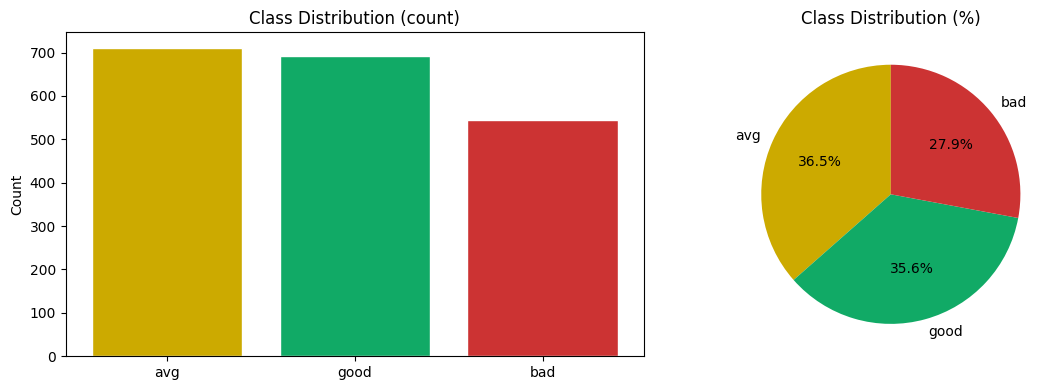

condition
avg     711
good    693
bad     544


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'good':'#1a6','avg':'#ca0','bad':'#c33'}

counts = df['condition'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors[c] for c in counts.index], edgecolor='white')
axes[0].set_title('Class Distribution (count)')
axes[0].set_ylabel('Count')

pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=pct.index, autopct='%1.1f%%',
            colors=[colors[c] for c in pct.index], startangle=90)
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(counts.to_string())


## Trips Overview

In [3]:
trip_summary = df.groupby(['trip_id','trip_name','condition']).size().unstack(fill_value=0)
print(trip_summary)


condition              avg  bad  good
trip_id trip_name                    
9       Trip 21:20:19  711  544   693


## Sensor Feature Distributions by Class

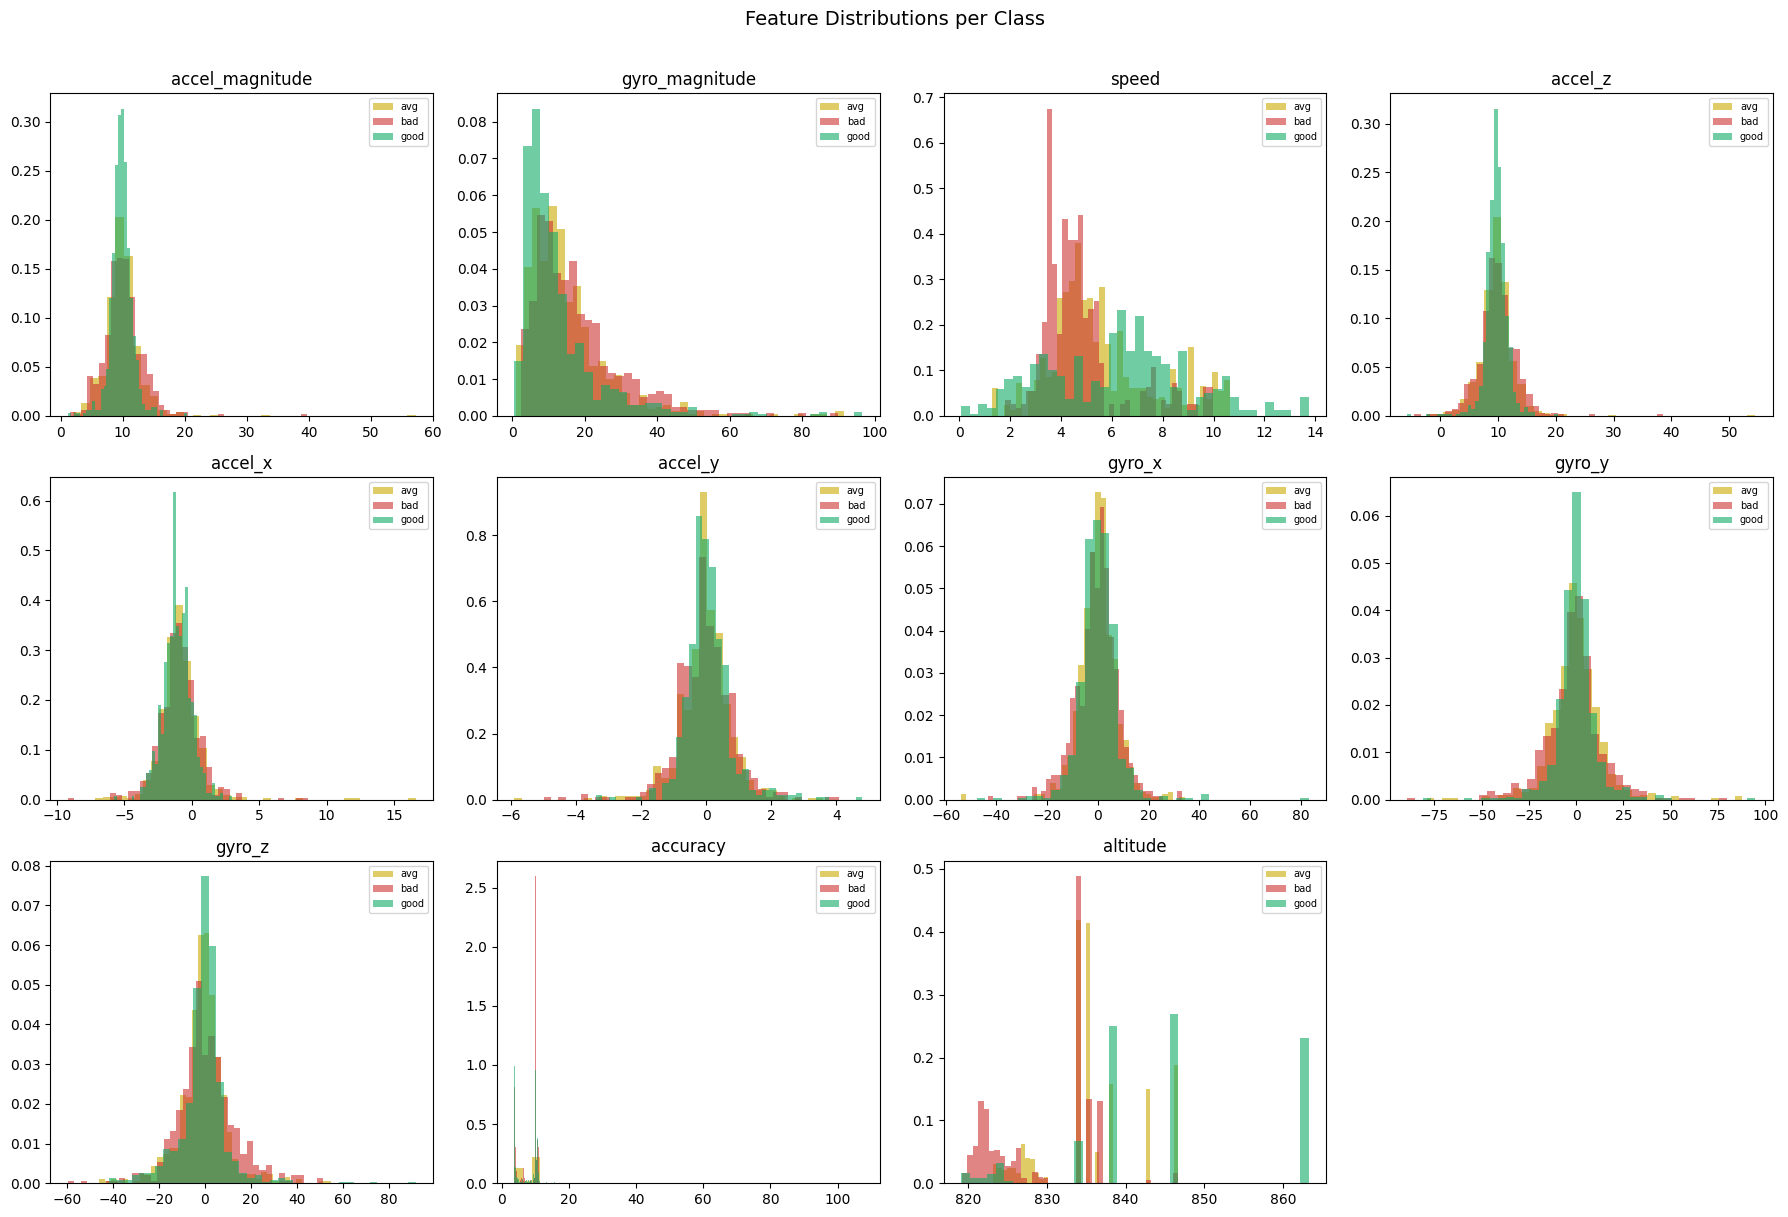

In [4]:
features = ['accel_magnitude','gyro_magnitude','speed','accel_z','accel_x','accel_y',
            'gyro_x','gyro_y','gyro_z','accuracy','altitude']
features = [f for f in features if f in df.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, feat in enumerate(features):
    for cond, grp in df.groupby('condition'):
        axes[i].hist(grp[feat].dropna(), bins=40, alpha=0.6,
                     label=cond, color=colors[cond], density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()


## Boxplots — Key Features vs Condition

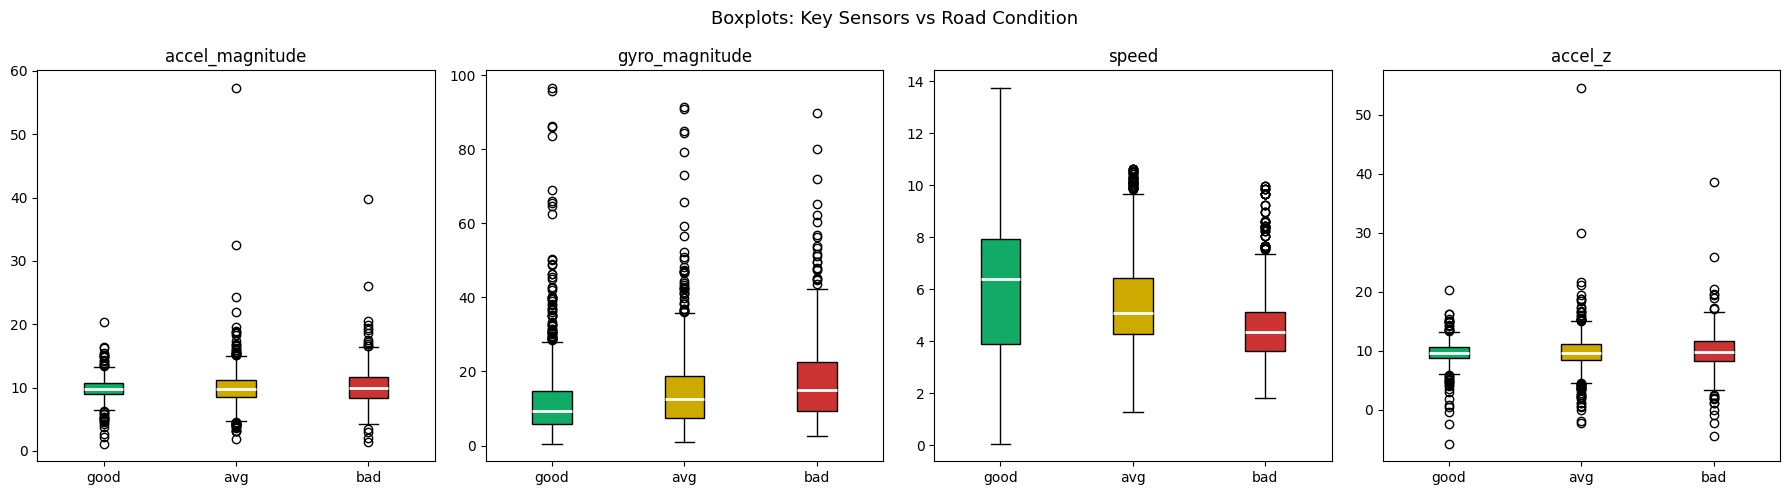

In [5]:
key = ['accel_magnitude','gyro_magnitude','speed','accel_z']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, key):
    order = ['good','avg','bad']
    data  = [df[df.condition==c][feat].dropna().values for c in order]
    bp = ax.boxplot(data, labels=order, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, c in zip(bp['boxes'], order):
        patch.set_facecolor(colors[c])
    ax.set_title(feat)
plt.suptitle('Boxplots: Key Sensors vs Road Condition', fontsize=13)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()


## Correlation Heatmap

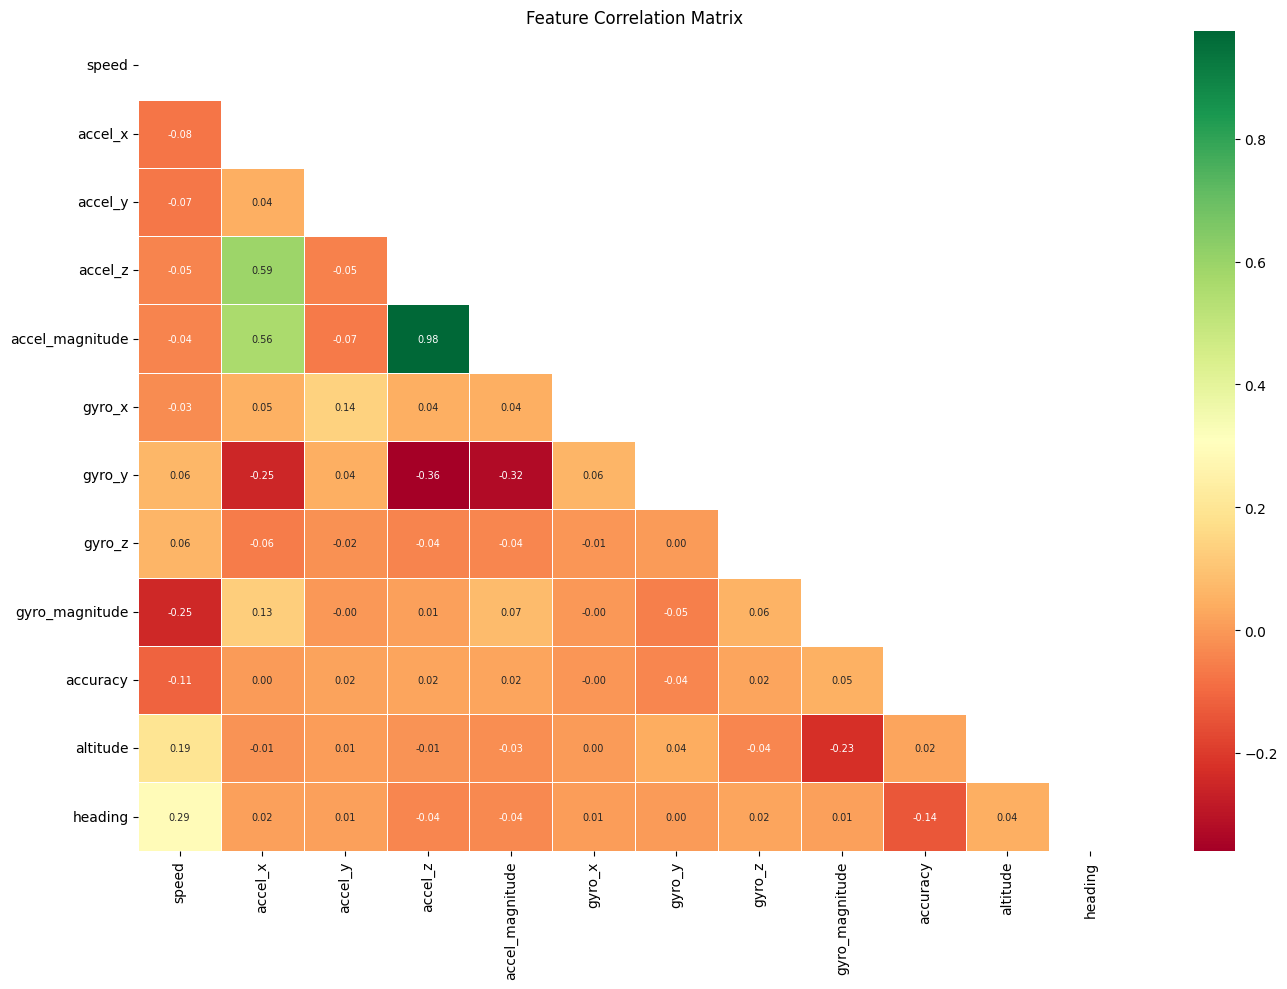

In [6]:
num_cols = df.select_dtypes(include=np.number).drop(
    columns=['id','trip_id','lat','lng'], errors='ignore')
corr = num_cols.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, annot_kws={'size':7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


## Missing Values

         missing   pct
heading        4  0.21
speed          3  0.15


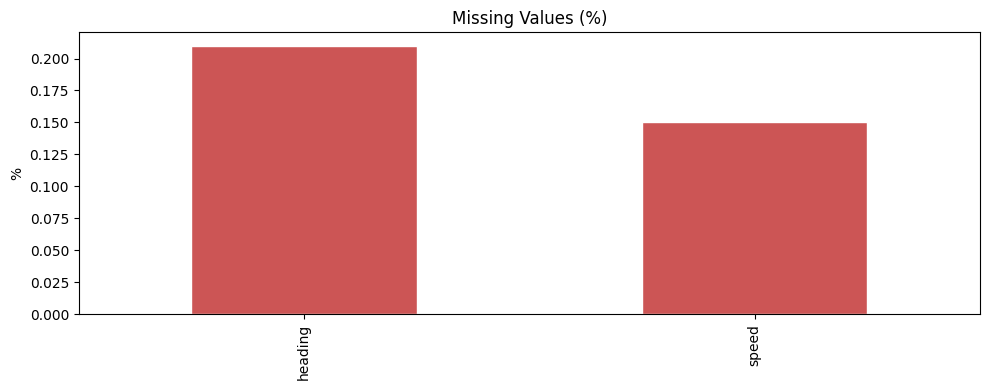

In [7]:
miss = df.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
summary = pd.DataFrame({'missing': miss, 'pct': miss_pct})
print(summary[summary.missing > 0])

plt.figure(figsize=(10,4))
miss_pct[miss_pct > 0].plot(kind='bar', color='#c55', edgecolor='white')
plt.title('Missing Values (%)')
plt.ylabel('%')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150)
plt.show()


## Speed vs Accel Magnitude (scatter by class)

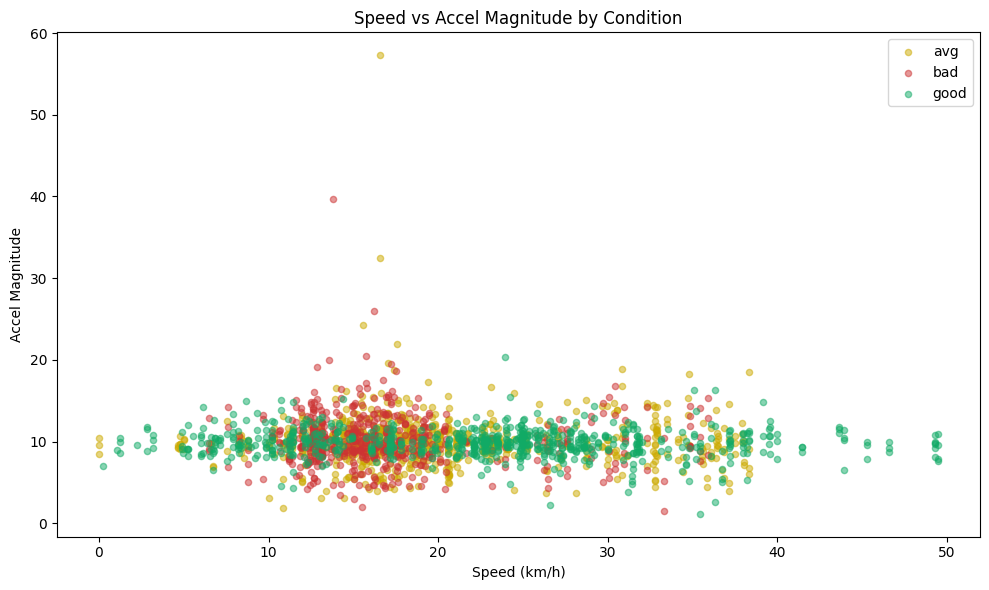

In [8]:
plt.figure(figsize=(10, 6))
for cond, grp in df.groupby('condition'):
    plt.scatter(grp['speed'].fillna(0)*3.6, grp['accel_magnitude'],
                alpha=0.5, label=cond, color=colors[cond], s=20)
plt.xlabel('Speed (km/h)')
plt.ylabel('Accel Magnitude')
plt.title('Speed vs Accel Magnitude by Condition')
plt.legend()
plt.tight_layout()
plt.savefig('speed_vs_accel.png', dpi=150)
plt.show()


## Per-Trip Timeline

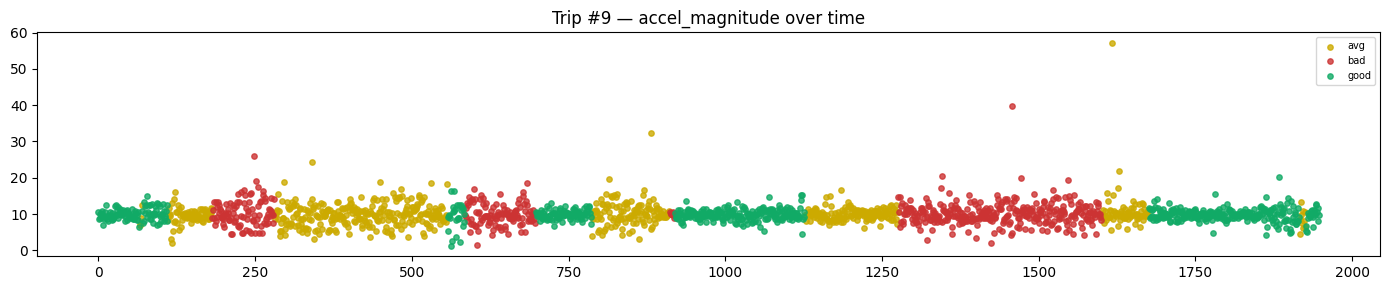

In [9]:
df['row_idx'] = df.groupby('trip_id').cumcount()
cmap = {'good':'#1a6','avg':'#ca0','bad':'#c33'}

trips = df['trip_id'].unique()[:6]  # show first 6 trips
fig, axes = plt.subplots(len(trips), 1, figsize=(14, 3*len(trips)), sharex=False)
if len(trips)==1: axes=[axes]

for ax, tid in zip(axes, trips):
    sub = df[df.trip_id==tid].copy()
    sub = sub.reset_index(drop=True)
    for cond, grp in sub.groupby('condition'):
        ax.scatter(grp.index, grp['accel_magnitude'],
                   color=cmap[cond], s=15, label=cond, alpha=0.8)
    ax.set_title(f"Trip #{tid} — accel_magnitude over time")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('trip_timelines.png', dpi=150)
plt.show()


## Summary Statistics per Class

In [10]:
feat_cols = ['accel_magnitude','gyro_magnitude','speed','accel_z','accel_x','accel_y']
feat_cols = [f for f in feat_cols if f in df.columns]
stats = df.groupby('condition')[feat_cols].agg(['mean','std','min','max'])
print(stats.to_string())
stats.to_csv('class_stats.csv')
print('\nSaved → class_stats.csv')


          accel_magnitude                          gyro_magnitude                               speed                              accel_z                        accel_x                        accel_y                    
                     mean       std    min     max           mean        std    min     max      mean       std       min    max      mean       std  min   max      mean       std  min   max      mean       std  min  max
condition                                                                                                                                                                                                                   
avg             10.004920  3.240775  1.931  57.277      15.238736  11.731872  0.883  91.406  5.617948  2.084979  1.290000  10.64  9.763291  3.339599 -2.3  54.5 -0.878340  1.650440 -7.2  16.6 -0.031505  0.797314 -5.9  3.6
bad             10.151675  3.149054  1.453  39.697      17.911414  12.197643  2.445  89.770  4.731654  1.596787  1.8